# 1. Introduction to Classification

Welcome! This notebook provides an in-depth introduction to **Classification**, a fundamental concept in supervised machine learning. We will explore its theoretical underpinnings, practical applications, and various evaluation metrics.

**Goal:** The primary goal of classification is to predict a categorical label (or class) for a given input. This means assigning data points to one of several predefined categories.

**Key Characteristics:**
-   **Discrete Output:** The model's output is a distinct category or class label.
-   **Supervised Learning:** Requires a dataset where each data point is already labeled with its correct class.
-   **Decision Boundaries:** Classification algorithms learn to draw boundaries (linear or non-linear) in the feature space to separate different classes.

**Common Applications:**
-   **Spam Detection:** Classifying emails as `spam` or `not spam`.
-   **Medical Diagnosis:** Predicting whether a patient has a certain disease (`positive` or `negative`).
-   **Customer Churn Prediction:** Identifying customers likely to `churn` (leave a service) or `not churn`.
-   **Image Recognition:** Categorizing images (e.g., `cat`, `dog`, `car`).
-   **Sentiment Analysis:** Determining the emotional tone of text (`positive`, `negative`, `neutral`).

We will use the famous **Iris dataset** to build our first classification model. This dataset contains measurements for 150 iris flowers from three different species, making it ideal for multi-class classification.

### Step 1: Import Libraries

First, let's import all the Python libraries we'll need for data manipulation, visualization, model building, and evaluation.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.datasets import load_iris

# Set a consistent style for our plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6) # Set default figure size

### Step 2: Load and Explore the Dataset

We'll load the Iris dataset, which is conveniently included with scikit-learn, and perform a thorough initial exploration to understand its structure, features, and target variable.

In [8]:
# Load the dataset
iris = load_iris()

# Create a pandas DataFrame for easier manipulation and viewing
# iris.data contains the feature values, iris.feature_names contains the names of these features
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target variable (the species of the flower) to the DataFrame
# iris.target contains numerical labels (0, 1, 2), and iris.target_names maps these to actual species names
df['species'] = iris.target
df['species'] = df['species'].apply(lambda x: iris.target_names[x])

print("--- Dataset Head (First 5 Rows) ---")
print(df.head())

print("--- Dataset Information ---")
df.info()

print("--- Basic Statistics of Numerical Features ---")
print(df.describe())

print("--- Distribution of Species (Target Variable) ---")
print(df['species'].value_counts())
print("Observation: The dataset is perfectly balanced with 50 samples for each of the three species.")

--- Dataset Head (First 5 Rows) ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float

### Step 3: Visualize the Data

Visualizing the data is crucial for understanding the relationships between different features and how they relate to the target variable. This can help us gain insights before building any models.

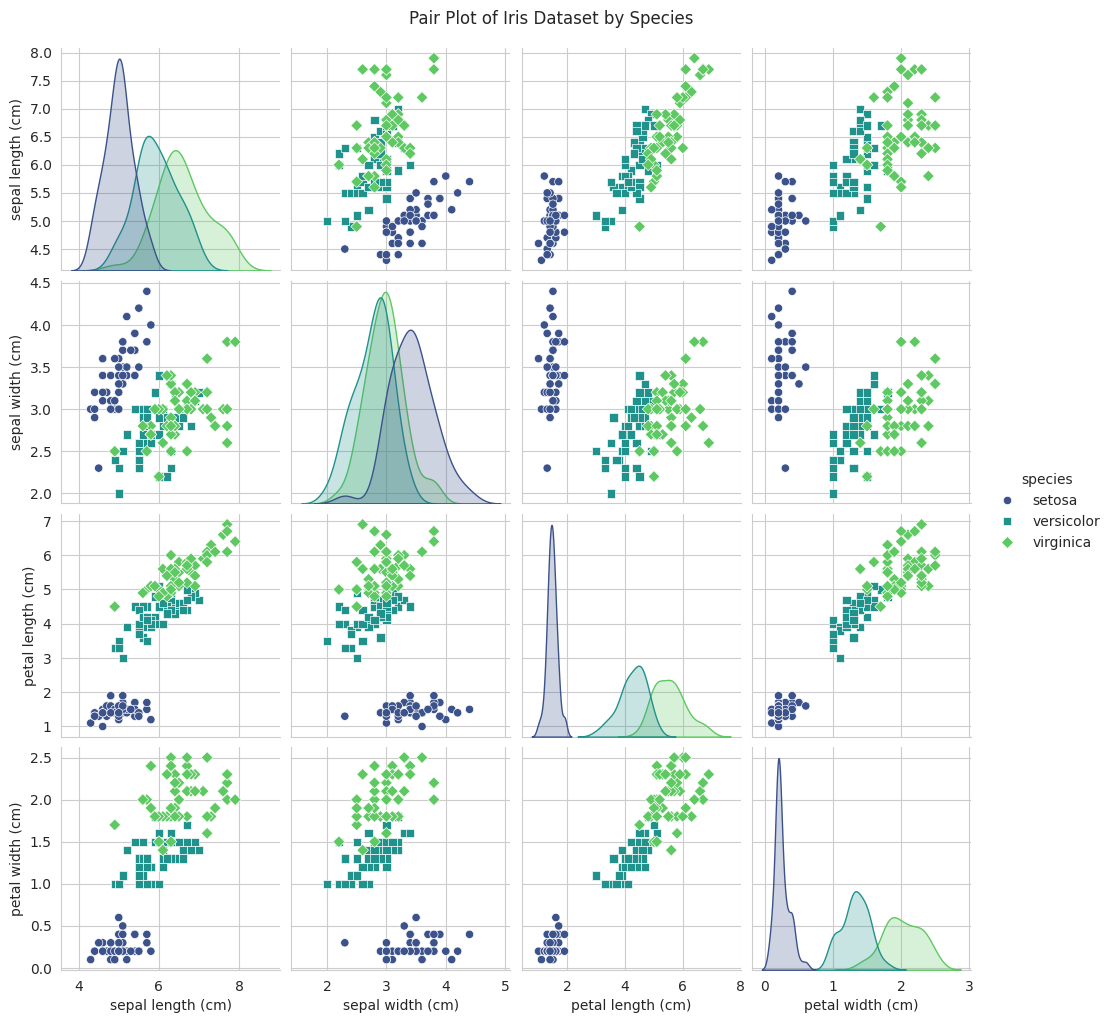

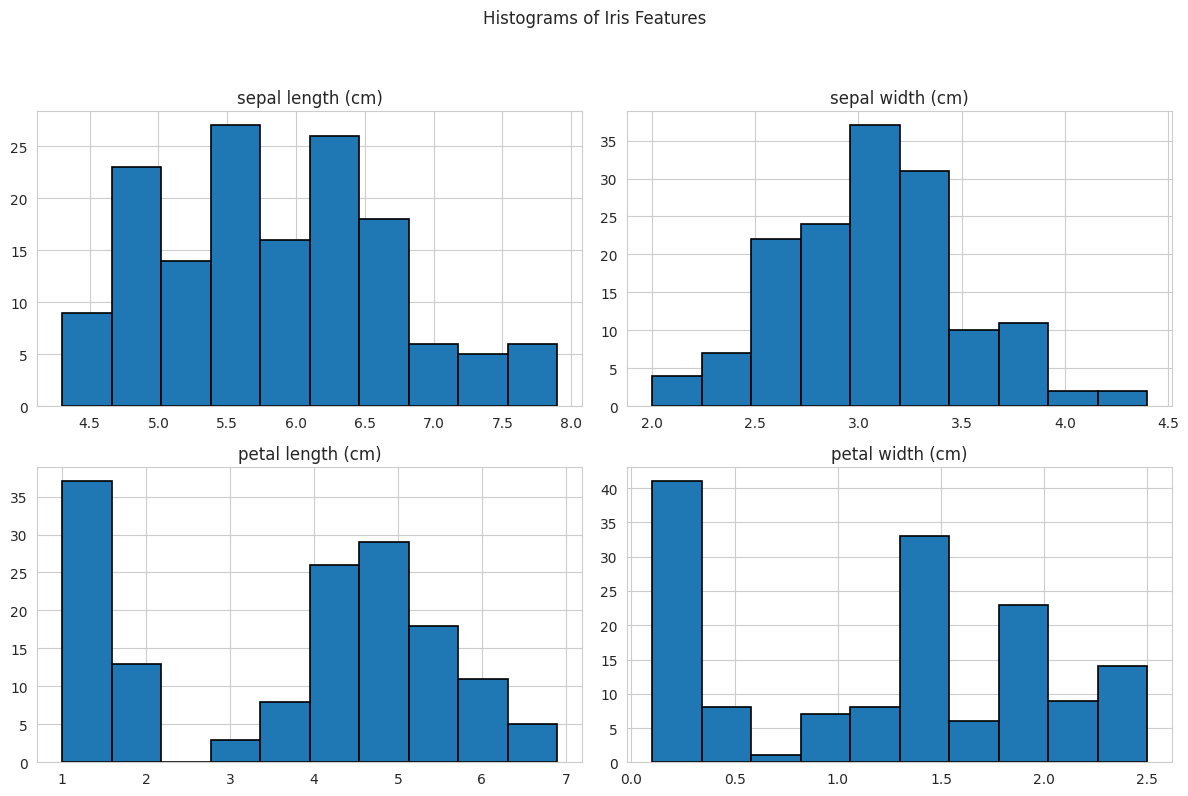

In [9]:
# Use seaborn's pairplot to visualize the relationships between all pairs of features
# We color the points by the 'species' column to see how well classes are separated
sns.pairplot(df, hue='species', markers=["o", "s", "D"], palette='viridis')
plt.suptitle("Pair Plot of Iris Dataset by Species", y=1.02) # Adjust title position
plt.show()

# Let's also look at the distribution of each feature
df.hist(edgecolor='black', linewidth=1.2, figsize=(12, 8))
plt.suptitle("Histograms of Iris Features", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

**Observation:** From the pair plots, we can clearly see that the 'setosa' species (purple/blue) is linearly separable from the other two based on petal length and width. 'Versicolor' and 'Virginica' (green and yellow) show some overlap, suggesting a more challenging classification task between them.

### Step 4: Prepare the Data for Modeling

Before training a model, we need to separate our dataset into features (the independent variables, usually denoted as `X`) and the target (the dependent variable we want to predict, usually denoted as `y`). We also need to convert the target species names back into numerical labels for scikit-learn models.

In [10]:
# X contains the features (all columns except 'species')
X = df.drop('species', axis=1)

# y contains the target variable ('species'), converted back to numerical labels (0, 1, 2)
y = iris.target # Use the original numerical target from load_iris()

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of X:")
print(X.head())
print("First 5 values of y:")
print(y[:5])

Shape of features (X): (150, 4)
Shape of target (y): (150,)
First 5 rows of X:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
First 5 values of y:
[0 0 0 0 0]


### Step 5: Split Data into Training and Testing Sets

It's crucial to evaluate our model's performance on data it has *never seen before*. To achieve this, we split our dataset into two parts:
1.  **Training Set:** Used to train (fit) our machine learning model. The model learns patterns from this data.
2.  **Testing Set:** Used to evaluate how well our trained model generalizes to new, unseen data. This set is kept separate during training.

We use `train_test_split` from `sklearn.model_selection`.
-   `test_size`: The proportion of the dataset to include in the test split (e.g., 0.2 for 20%).
-   `random_state`: A seed for the random number generator. Setting this ensures that your split is the same every time you run the code, which is vital for reproducibility.
-   `stratify`: Ensures that the proportion of samples for each class is roughly the same in both the training and testing sets as it is in the full dataset. This is especially important for imbalanced datasets.

In [11]:
# Split the data: 80% for training, 20% for testing
# random_state ensures reproducibility
# stratify=y ensures that the proportion of each species is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print("Distribution of species in training set:")
print(pd.Series(y_train).value_counts())
print("Distribution of species in testing set:")
print(pd.Series(y_test).value_counts())

Training set size: 120 samples
Testing set size: 30 samples
Distribution of species in training set:
0    40
2    40
1    40
Name: count, dtype: int64
Distribution of species in testing set:
0    10
2    10
1    10
Name: count, dtype: int64


### Step 6: Train a Classification Model

We will start with a **Decision Tree Classifier**. Decision Trees are intuitive models that make decisions based on a series of 'if-then-else' rules inferred from the features. They are easy to visualize and understand.

In [12]:
# Create an instance of the DecisionTreeClassifier
# random_state for reproducibility of the tree structure
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


#### Visualizing the Decision Tree

One of the great advantages of Decision Trees is their interpretability. We can visualize the decision-making process.

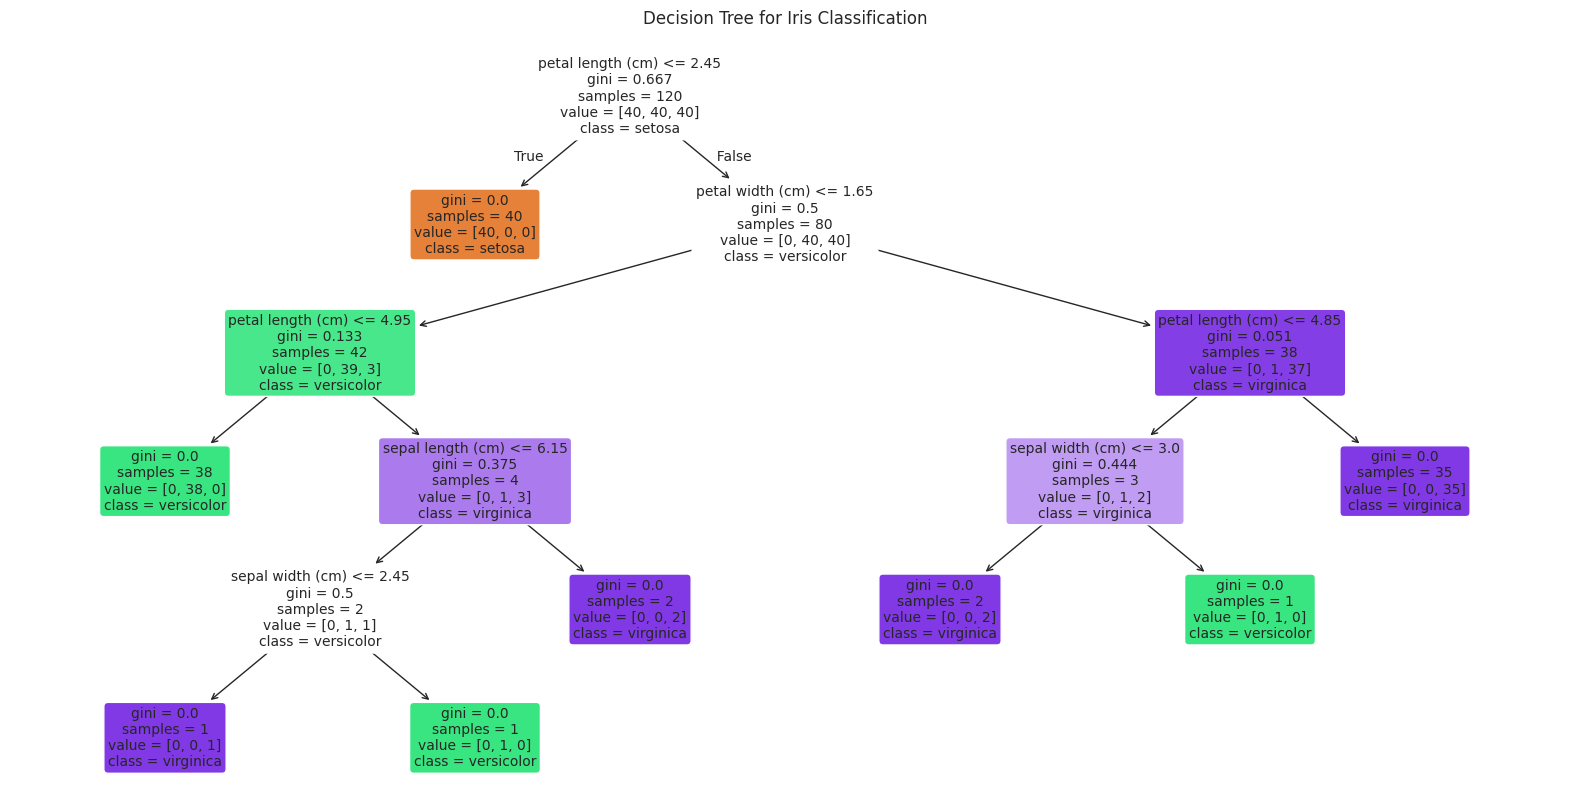

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Iris Classification")
plt.show()

### Step 7: Evaluate the Model

After training, we need to assess how well our model performs on unseen data. We use the testing set for this purpose. Several metrics are available for classification tasks.

In [14]:
# Make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# Calculate the accuracy of the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Model Accuracy: {accuracy_dt:.4f}")

Decision Tree Model Accuracy: 0.9333


#### Confusion Matrix

A **Confusion Matrix** is a powerful tool to understand the model's performance in more detail than just accuracy. It shows the number of correct and incorrect predictions made by the classifier, broken down by each class.

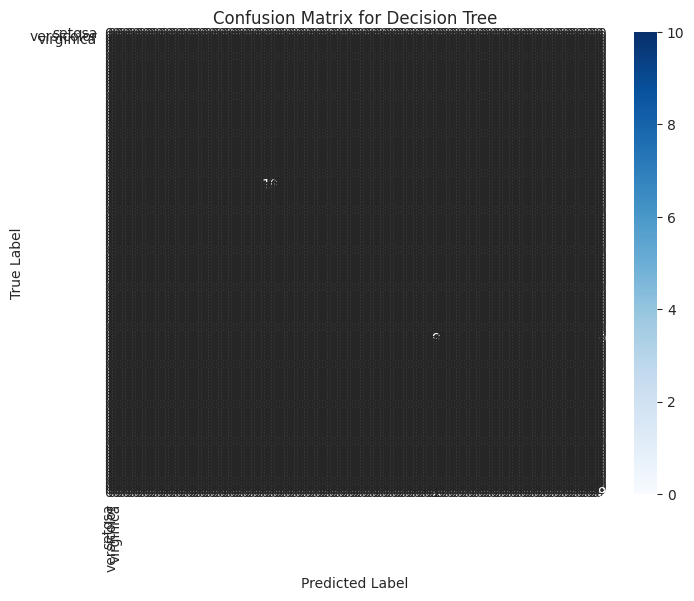

In [15]:
# Generate the confusion matrix
# labels parameter ensures the order of classes in the matrix
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=iris.target)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Decision Tree")
plt.show()

#### Classification Report

The **Classification Report** provides a summary of precision, recall, F1-score, and support for each class. These metrics are particularly useful when dealing with imbalanced datasets, where accuracy alone can be misleading.

In [16]:
# Print a detailed classification report
# target_names maps numerical labels back to original species names for readability
print("Classification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=iris.target_names))

Classification Report for Decision Tree:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Step 8: Experiment with Other Classifiers

Let's try two other common classification algorithms: **K-Nearest Neighbors (KNN)** and **Logistic Regression**, and compare their performance.

#### K-Nearest Neighbors (KNN)

KNN is a non-parametric, lazy learning algorithm. It classifies a new data point based on the majority class among its `k` nearest neighbors in the feature space.

In [30]:
# Create and train a KNN model
knn_model = KNeighborsClassifier(n_neighbors=1) # Try different values for k
knn_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Model Accuracy: {accuracy_knn:.4f}")
print("Classification Report for KNN:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

KNN Model Accuracy: 0.9667
Classification Report for KNN:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



#### Logistic Regression

Despite its name, Logistic Regression is a linear model for classification, not regression. It models the probability that a given input belongs to a particular class.

In [18]:
# Create and train a Logistic Regression model
# max_iter increased for convergence, C is regularization strength
lr_model = LogisticRegression(random_state=42, max_iter=200)
lr_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Model Accuracy: {accuracy_lr:.4f}")
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))

Logistic Regression Model Accuracy: 0.9667
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Step 9: Make a Prediction on New Data

Let's pretend we found a new iris flower and measured its features. We can use our trained models to predict its species. Remember that the models expect the input features in the same order and scale as the training data.

In [31]:
# New flower data: [sepal length, sepal width, petal length, petal width]
# This corresponds to a known 'setosa' flower
new_flower_setosa = np.array([[5.1, 3.5, 1.4, 0.2]])

# This corresponds to a known 'virginica' flower
new_flower_virginica = np.array([[6.3, 3.3, 6.0, 2.5]])

print(f"Decision Tree predicts for Setosa-like flower: {iris.target_names[dt_model.predict(new_flower_setosa)[0]]}")
print(f"KNN predicts for Setosa-like flower: {iris.target_names[knn_model.predict(new_flower_setosa)[0]]}")
print(f"Logistic Regression predicts for Setosa-like flower: {iris.target_names[lr_model.predict(new_flower_setosa)[0]]}")

print(f"Decision Tree predicts for Virginica-like flower: {iris.target_names[dt_model.predict(new_flower_virginica)[0]]}")
print(f"KNN predicts for Virginica-like flower: {iris.target_names[knn_model.predict(new_flower_virginica)[0]]}")
print(f"Logistic Regression predicts for Virginica-like flower: {iris.target_names[lr_model.predict(new_flower_virginica)[0]]}")

Decision Tree predicts for Setosa-like flower: setosa
KNN predicts for Setosa-like flower: setosa
Logistic Regression predicts for Setosa-like flower: setosa
Decision Tree predicts for Virginica-like flower: virginica
KNN predicts for Virginica-like flower: virginica
Logistic Regression predicts for Virginica-like flower: virginica


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/pyt

### Mini-Challenges / Further Exploration

1.  **Feature Importance (Decision Tree):** Decision Trees can tell you which features were most important for making decisions. Access `dt_model.feature_importances_` and map them back to `iris.feature_names`. Which features were most influential?
2.  **ROC Curve (Binary Classification):** For binary classification problems, the Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC) are important metrics. While Iris is multi-class, you could simplify it to a binary problem (e.g., 'setosa' vs. 'non-setosa') and plot the ROC curve for one of your models.
3.  **Impact of `random_state`:** Remove the `random_state` parameter from `train_test_split` and `DecisionTreeClassifier` and run the notebook multiple times. Observe how the results (accuracy, tree structure) might change. Why is `random_state` crucial for reproducibility in machine learning experiments?
4.  **Hyperparameter Tuning (Manual):** For the KNN model, try different values for `n_neighbors` (e.g., 1, 5, 10, 15). How does changing `k` affect the accuracy and the classification report? What happens if `k` is too small or too large?